# Kore2 Motorcycle Battery — State of Health Investigation
### Are the customer complaints a fleet-wide design fault, or a few defective units hiding in a healthy fleet?

---

*CRISP-DM structured analysis of KOFA e-boda battery telemetry.*


## 0. Introduction

KOFA operates a battery-swap network for Kenya's electric motorcycle (*boda boda*) riders. Riders have filed complaints that some batteries **drain unusually fast** and **shut down mid-ride** while the display still shows remaining charge — stranding the rider, sometimes with a passenger, sometimes in traffic.

This notebook investigates one fleet sample of **12 Kore2 batteries** to answer a single, business-critical question:

> **Is this a design-level defect affecting the entire Kore2 battery model, or a small, identifiable group of faulty units inside an otherwise healthy fleet?**

The two answers lead to completely different actions. A design fault means a full product recall and a supplier renegotiation. A bad-unit problem means pulling a handful of batteries and auditing one manufacturing batch. Getting this distinction right — with evidence — is the entire value of the analysis.

The notebook follows the **CRISP-DM** framework end to end: Business Understanding → Data Understanding → Data Preparation → Modeling → Evaluation → Deployment → Recommendations.


## 1. Business Understanding

**The problem in business terms.** Every battery that drains fast or cuts out early is a lost fare, a rider complaint, and a step toward that rider leaving the platform. In a market where riders talk to each other constantly, a reputation for unreliable batteries spreads fast and is expensive to reverse. But over-reacting is also costly: recalling an entire battery model that is mostly healthy wastes capital and damages supplier relationships over a problem that may sit in a handful of units.

**Why the distinction matters commercially:**

| If the cause is… | Then the right action is… | Cost profile |
|---|---|---|
| A **fleet-wide design fault** | Recall the whole Kore2 line; renegotiate with the OEM | Very high, sector-wide |
| A **small batch of defective units** | Pull the specific units; audit their production batch | Low, targeted |

**Success criteria for this analysis:**

1. Determine, with statistical evidence, whether poor performance is confined to specific units or spread across the fleet.
2. Identify *which* batteries (by ID) are defective, if any.
3. Rule out — or flag — obvious external confounds (e.g. heat, route) so the conclusion points at the batteries themselves.
4. Produce a screening rule that can be reused on future telemetry as an early-warning system, before a rider is stranded.

**Analytical question.** Can we separate the fleet into "healthy" and "faulty" groups using only telemetry (charge, voltage, health, ride behaviour), cleanly enough to act on?


## 2. Data Understanding

Before any cleaning or modeling, we look at what the raw data actually contains — its size, columns, time span, quality issues, and the overall behaviour of the fleet — *before* we decide who is healthy and who is not.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.titlesize': 13, 'axes.titleweight': 'bold', 'font.size': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
})

# Two colours used consistently throughout: blue = healthy, red = flagged.
NORMAL_COLOR = '#4C72B0'
FLAG_COLOR   = '#C44E52'

# Load the raw telemetry. parse_dates turns the timestamp text into real datetimes
# so we can do time-based maths (durations, sorting) later.
df = pd.read_csv('Kore2_battery_performance.csv', parse_dates=['timestamp'])
df = df.sort_values(['battery_id', 'timestamp']).reset_index(drop=True)

print(f"Rows: {len(df):,}")
print(f"Batteries: {df['battery_id'].nunique()}  ->  {sorted(df['battery_id'].unique())}")
print(f"Time window: {df['timestamp'].min()}  to  {df['timestamp'].max()}")
df.head()

Rows: 8,640
Batteries: 12  ->  ['KF-A100', 'KF-B101', 'KF-C102', 'KF-D103', 'KF-E104', 'KF-F105', 'KF-G106', 'KF-H107', 'KF-I108', 'KF-J109', 'KF-K110', 'KF-L111']
Time window: 2025-10-22 08:00:00  to  2025-10-22 13:59:30


,timestamp,battery_id,state,speed_kph,voltage_V,current_A,soc_percent,state_of_health,ambient_temp_C
0,2025-10-22 08:00:00,KF-A100,in_use,40.236637,55.941068,4.428398,99.888541,96.633692,25.776328
1,2025-10-22 08:00:30,KF-A100,in_use,36.093750,56.014336,4.457854,99.776258,96.633692,25.650893
2,2025-10-22 08:01:00,KF-A100,in_use,33.435760,55.939064,5.530376,99.636856,96.633692,NaN
3,2025-10-22 08:01:30,KF-A100,in_use,37.703857,55.993686,NaN,99.513252,96.633692,25.382408
4,2025-10-22 08:02:00,KF-A100,in_use,39.959803,55.987407,4.484439,99.400047,96.633692,25.643806


**What each column means:**

| Column | Meaning |
|---|---|
| `timestamp` | Reading time, one row every 30 seconds |
| `battery_id` | Which of the 12 batteries (KF-A100 … KF-L111) |
| `state` | What the battery is doing: `in_use` (riding), `charging`, or `not_in_use` (parked) |
| `speed_kph` | Motorcycle speed at that moment |
| `voltage_V` | Pack voltage |
| `current_A` | Current draw |
| `soc_percent` | **State of Charge** — how full the battery is (0–100%) |
| `state_of_health` | **State of Health (SOH)** — the pack's own long-term health estimate |
| `ambient_temp_C` | Surrounding temperature |


In [2]:
# How the readings split across the three states, and how much data is missing.
print("Rows per state:")
print(df['state'].value_counts(), "\n")

print("Missing values per column:")
missing = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(1)
print(pd.DataFrame({'missing': missing, 'pct': missing_pct}))

Rows per state:
state
charging      4553
in_use        2924
not_in_use    1163
Name: count, dtype: int64 

Missing values per column:
                 missing  pct
timestamp              0  0.0
battery_id             0  0.0
state                  0  0.0
speed_kph            430  5.0
voltage_V            420  4.9
current_A            462  5.3
soc_percent          437  5.1
state_of_health      415  4.8
ambient_temp_C       422  4.9


**First read on data quality.** Roughly 5% of the numeric sensor readings are missing, spread fairly evenly across every measured column — the kind of scattered gaps you get from ordinary telemetry dropouts, not a systematic failure of one sensor. The `timestamp`, `battery_id` and `state` columns are complete. We will handle the gaps in Data Preparation rather than dropping whole rows, since even partial readings are useful.

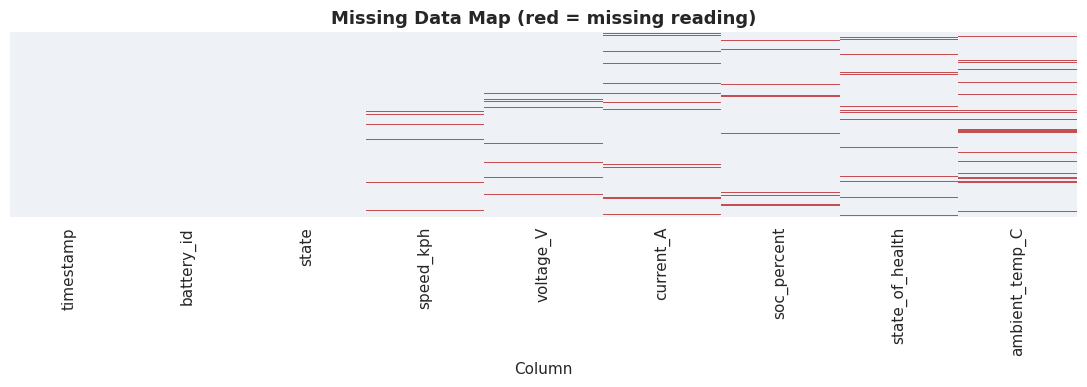

In [3]:
# Missing-data heatmap: is missingness random, or clustered in one battery / column?
plt.figure(figsize=(11, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False,
            cmap=['#eef2f7', FLAG_COLOR])
plt.title('Missing Data Map (red = missing reading)')
plt.xlabel('Column')
plt.tight_layout()
plt.show()

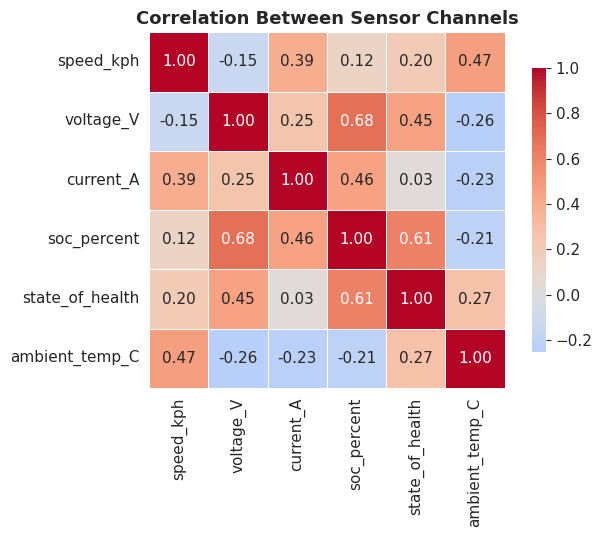

In [4]:
# Correlation between the numeric sensor channels — a first look at how they move together.
num_cols = ['speed_kph', 'voltage_V', 'current_A', 'soc_percent', 'state_of_health', 'ambient_temp_C']
plt.figure(figsize=(7, 5.5))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Between Sensor Channels')
plt.tight_layout()
plt.show()

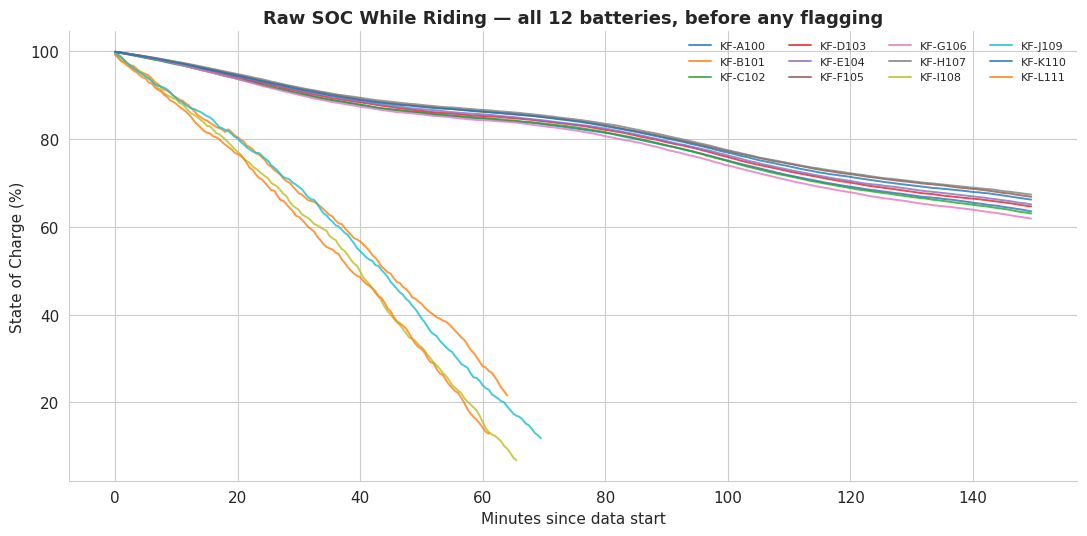

In [5]:
# THE key exploratory view: raw State-of-Charge over time for all 12 batteries while riding,
# BEFORE we flag anyone. If the fleet were uniform, the lines would bunch together.
plt.figure(figsize=(11, 5.5))
for bid, g in df.groupby('battery_id'):
    ride = g[g['state'] == 'in_use'].dropna(subset=['soc_percent']).sort_values('timestamp')
    if ride.empty:
        continue
    t_min = (ride['timestamp'] - df['timestamp'].min()).dt.total_seconds() / 60
    plt.plot(t_min, ride['soc_percent'], linewidth=1.4, alpha=0.8, label=bid)

plt.xlabel('Minutes since data start')
plt.ylabel('State of Charge (%)')
plt.title('Raw SOC While Riding — all 12 batteries, before any flagging')
plt.legend(ncol=4, fontsize=8, frameon=False)
plt.tight_layout()
plt.show()

**What the raw picture already shows.** Without doing any statistics yet, the SOC curves split into two visually distinct bundles: most batteries drain gently and are still riding well past the two-hour mark, while a small group plunges steeply and drops out early. This is the pattern the rest of the notebook will confirm and quantify — but it is worth noticing that the signal is strong enough to see with the naked eye. That is a good sign for a clean result.

## 3. Data Preparation

We turn 8,640 raw 30-second readings into **one summary row per battery**, carrying the handful of engineered metrics that actually describe battery health. This is where the analysis-ready dataset is built.

**Engineered features (one value per battery):**

- **Drain rate** (`drain_rate_pct_per_hr`) — how fast SOC falls while riding, from a linear fit of SOC vs. time (a fit is more robust to noisy individual readings than a simple start-minus-end).
- **Ride duration** (`ride_duration_min`) — minutes from first to last riding reading; a proxy for how long the battery lasted before it stopped.
- **SOC at shutdown** (`soc_at_shutdown`) — the charge still showing when riding stopped; a *high* value means it cut out with charge to spare.
- **Voltage stability** (`voltage_std_inuse`) — standard deviation of voltage under load; healthy packs hold a tight band, failing packs sag and spike.
- **State of Health** (`soh_pct`) — the pack's own reported health, used as an independent cross-check.
- **Mean ambient temperature** (`temp_mean`) — to check whether heat, not the battery, explains poor performance.


In [6]:
# Missing values are scattered telemetry dropouts. We keep every row and fill numeric gaps
# per battery using linear interpolation over time (then forward/backfill any edge gaps),
# which respects the fact that SOC, voltage etc. change smoothly rather than jumping.
num_cols = ['speed_kph', 'voltage_V', 'current_A', 'soc_percent', 'state_of_health', 'ambient_temp_C']

df_clean = df.copy()
df_clean[num_cols] = (
    df_clean.groupby('battery_id')[num_cols]
            .apply(lambda g: g.interpolate(method='linear', limit_direction='both'))
            .reset_index(level=0, drop=True)
)
print("Missing values remaining after interpolation:")
print(df_clean[num_cols].isnull().sum())

Missing values remaining after interpolation:
speed_kph          0
voltage_V          0
current_A          0
soc_percent        0
state_of_health    0
ambient_temp_C     0
dtype: int64


In [7]:
# Build the one-row-per-battery summary table.
rows = []
for bid, g in df_clean.groupby('battery_id'):
    ride = g[g['state'] == 'in_use'].dropna(subset=['soc_percent', 'timestamp']).sort_values('timestamp')

    # Drain rate: slope of SOC vs elapsed hours, negated so a positive number = %/hour lost.
    t_hr = (ride['timestamp'] - ride['timestamp'].iloc[0]).dt.total_seconds() / 3600
    drain_rate = -np.polyfit(t_hr, ride['soc_percent'], 1)[0]

    # Ride duration in minutes (first to last in-use reading).
    ride_min = (ride['timestamp'].iloc[-1] - ride['timestamp'].iloc[0]).total_seconds() / 60

    # SOC at the moment riding stopped (last in-use reading).
    soc_at_shutdown = ride['soc_percent'].iloc[-1]

    rows.append(dict(
        battery_id        = bid,
        drain_rate_pct_per_hr = round(drain_rate, 2),
        ride_duration_min = round(ride_min, 1),
        soc_at_shutdown   = round(soc_at_shutdown, 2),
        voltage_std_inuse = round(ride['voltage_V'].std(), 2),
        soh_pct           = round(g['state_of_health'].mean(), 2),
        temp_mean         = round(g['ambient_temp_C'].mean(), 1),
    ))

summary = pd.DataFrame(rows).sort_values('drain_rate_pct_per_hr', ascending=False).reset_index(drop=True)
summary

,battery_id,drain_rate_pct_per_hr,ride_duration_min,soc_at_shutdown,voltage_std_inuse,soh_pct,temp_mean
0,KF-I108,85.93,65.5,6.83,4.39,80.42,26.9
1,KF-L111,84.41,61.0,12.90,4.27,66.85,25.8
2,KF-J109,77.88,69.5,11.89,2.84,73.52,26.2
3,KF-B101,71.55,64.0,21.59,2.38,71.45,25.6
4,KF-G106,15.07,149.5,61.89,0.77,98.36,27.8
5,KF-C102,14.51,149.5,63.06,0.74,92.13,29.0
6,KF-A100,14.32,149.5,63.55,0.73,96.63,25.7
7,KF-D103,14.00,149.5,64.67,0.71,98.41,25.6
8,KF-E104,13.85,149.5,65.13,0.70,93.07,26.2
9,KF-K110,13.44,149.5,66.23,0.69,98.23,29.0


## 4. Modeling

**The modeling choice — and why the naive one fails here.** The obvious approach is a z-score / control-limit test: flag any battery more than 2 standard deviations from the fleet mean. **That approach breaks on this dataset.** With 4 of 12 batteries being extreme, those 4 drag the mean and standard deviation so far upward that *they no longer look far from the mean* — the worst battery lands at only ~1.5σ, below the 2σ threshold, and **nothing gets flagged.** (This is the classic weakness of mean/σ methods under heavy contamination.)

The Data Understanding plots already told us the real structure: the fleet is not one cloud with a few stragglers, it is **two distinct populations**. So we model it that way — with **K-Means clustering (k=2)** on the standardised health metrics. Clustering finds the two natural groups directly, without assuming a single center, and is unaffected by how extreme the bad group is.


In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# First, demonstrate WHY the naive z-score approach fails on this data.
dr = summary['drain_rate_pct_per_hr']
z = (dr - dr.mean()) / dr.std()
print("Naive z-score test on drain rate (flag if z > 2):")
print(f"  Highest z-score in the fleet: {z.max():.2f}  ->  threshold is 2.0")
print(f"  Batteries flagged by z-score: {summary.loc[z > 2, 'battery_id'].tolist()}")
print("  => the method flags NObody, because the outliers inflate the mean and std.\n")

Naive z-score test on drain rate (flag if z > 2):
  Highest z-score in the fleet: 1.53  ->  threshold is 2.0
  Batteries flagged by z-score: []
  => the method flags NObody, because the outliers inflate the mean and std.



In [9]:
# The correct model: cluster the batteries into 2 natural groups on their health metrics.
features = ['drain_rate_pct_per_hr', 'ride_duration_min', 'soc_at_shutdown',
            'voltage_std_inuse', 'soh_pct']
X = StandardScaler().fit_transform(summary[features])

km = KMeans(n_clusters=2, n_init=10, random_state=42)
summary['cluster'] = km.fit_predict(X)

# The "faulty" cluster is whichever one has the higher average drain rate.
faulty_cluster = summary.groupby('cluster')['drain_rate_pct_per_hr'].mean().idxmax()
summary['flagged'] = summary['cluster'] == faulty_cluster
flagged_ids = summary.loc[summary['flagged'], 'battery_id'].tolist()

print(f"Batteries flagged as FAULTY by K-Means (k=2): {flagged_ids}")
print(f"Batteries healthy: {summary.loc[~summary['flagged'], 'battery_id'].tolist()}")
summary

Batteries flagged as FAULTY by K-Means (k=2): ['KF-I108', 'KF-L111', 'KF-J109', 'KF-B101']
Batteries healthy: ['KF-G106', 'KF-C102', 'KF-A100', 'KF-D103', 'KF-E104', 'KF-K110', 'KF-F105', 'KF-H107']


,battery_id,drain_rate_pct_per_hr,ride_duration_min,soc_at_shutdown,voltage_std_inuse,soh_pct,temp_mean,cluster,flagged
0,KF-I108,85.93,65.5,6.83,4.39,80.42,26.9,1,True
1,KF-L111,84.41,61.0,12.90,4.27,66.85,25.8,1,True
2,KF-J109,77.88,69.5,11.89,2.84,73.52,26.2,1,True
3,KF-B101,71.55,64.0,21.59,2.38,71.45,25.6,1,True
4,KF-G106,15.07,149.5,61.89,0.77,98.36,27.8,0,False
5,KF-C102,14.51,149.5,63.06,0.74,92.13,29.0,0,False
6,KF-A100,14.32,149.5,63.55,0.73,96.63,25.7,0,False
7,KF-D103,14.00,149.5,64.67,0.71,98.41,25.6,0,False
8,KF-E104,13.85,149.5,65.13,0.70,93.07,26.2,0,False
9,KF-K110,13.44,149.5,66.23,0.69,98.23,29.0,0,False


## 5. Evaluation

We now test whether the two clusters are a **real, clean separation** or a fragile one — and whether an external factor (heat) could explain the split instead of the batteries themselves.


In [10]:
# 5a. Is the gap between the two groups clean, or are there borderline cases?
comp = summary.groupby('flagged')[features + ['temp_mean']].mean().round(2)
comp.index = ['Healthy (8)', 'Faulty (4)']
print("Group averages — Healthy vs Faulty:")
print(comp.T, "\n")

# Largest gap in sorted drain rate = the "clean break" between populations.
sorted_dr = np.sort(summary['drain_rate_pct_per_hr'].values)
gaps = np.diff(sorted_dr)
print(f"Largest gap between consecutive batteries' drain rates: {gaps.max():.1f} %/hr")
print(f"Next-largest gap anywhere else:                        {np.sort(gaps)[-2]:.1f} %/hr")
print("=> the between-group gap dwarfs any within-group gap: a clean bimodal split.")

Group averages — Healthy vs Faulty:
                       Healthy (8)  Faulty (4)
drain_rate_pct_per_hr        13.93       79.94
ride_duration_min           149.50       65.00
soc_at_shutdown              64.84       13.30
voltage_std_inuse             0.71        3.47
soh_pct                      96.55       73.06
temp_mean                    27.16       26.12 

Largest gap between consecutive batteries' drain rates: 56.5 %/hr
Next-largest gap anywhere else:                        6.5 %/hr
=> the between-group gap dwarfs any within-group gap: a clean bimodal split.


In [11]:
# 5b. Rule out heat as a confound: if faulty batteries were just hotter, temp would differ.
print("Ambient temperature by group:")
print(summary.groupby('flagged')['temp_mean'].agg(['mean', 'min', 'max']).round(1))
print("\n=> temperatures overlap almost entirely; heat does NOT explain the split.")

Ambient temperature by group:
         mean   min   max
flagged                  
False    27.2  25.6  29.0
True     26.1  25.6  26.9

=> temperatures overlap almost entirely; heat does NOT explain the split.


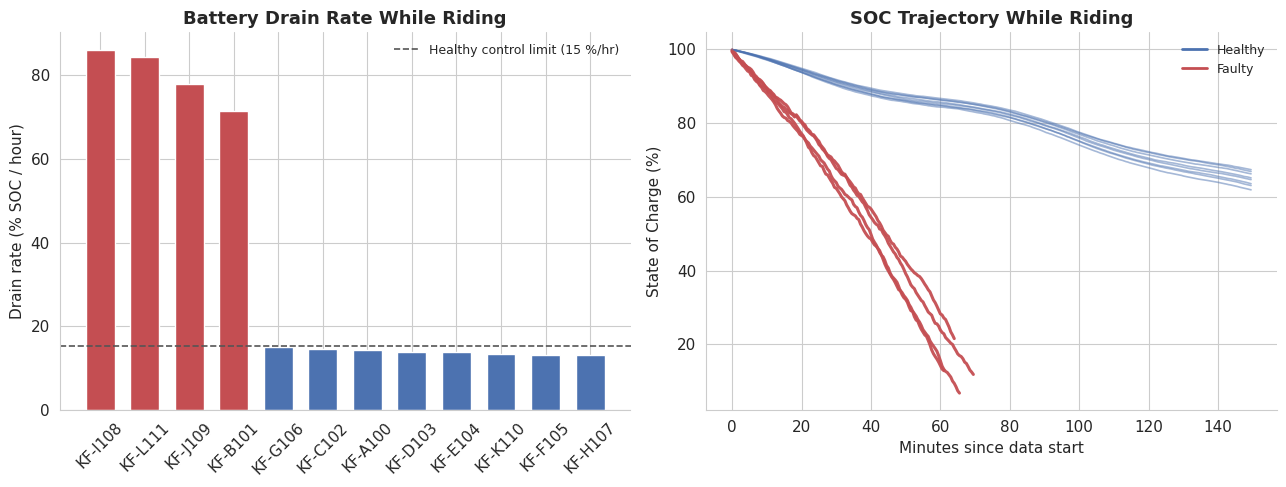

In [12]:
# 5c. Visual confirmation: the headline evidence chart, now correctly colour-coded.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: drain rate per battery with a control limit built from HEALTHY batteries only.
plot_df = summary.sort_values('drain_rate_pct_per_hr', ascending=False)
colors = [FLAG_COLOR if f else NORMAL_COLOR for f in plot_df['flagged']]
healthy = summary.loc[~summary['flagged'], 'drain_rate_pct_per_hr']
limit = healthy.mean() + 2 * healthy.std()

ax = axes[0]
ax.bar(plot_df['battery_id'], plot_df['drain_rate_pct_per_hr'], color=colors, width=0.65)
ax.axhline(limit, color='#555', ls='--', lw=1.2,
           label=f'Healthy control limit ({limit:.0f} %/hr)')
ax.set_ylabel('Drain rate (% SOC / hour)')
ax.set_title('Battery Drain Rate While Riding')
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=9, frameon=False)

# Right: SOC trajectories, faulty batteries highlighted.
ax2 = axes[1]
for bid, g in df_clean.groupby('battery_id'):
    ride = g[g['state'] == 'in_use'].dropna(subset=['soc_percent']).sort_values('timestamp')
    if ride.empty:
        continue
    t = (ride['timestamp'] - df_clean['timestamp'].min()).dt.total_seconds() / 60
    is_flag = bid in flagged_ids
    ax2.plot(t, ride['soc_percent'],
             color=FLAG_COLOR if is_flag else NORMAL_COLOR,
             lw=2.2 if is_flag else 1.2, alpha=0.95 if is_flag else 0.5)

from matplotlib.lines import Line2D
ax2.legend(handles=[Line2D([0],[0], color=NORMAL_COLOR, lw=2, label='Healthy'),
                    Line2D([0],[0], color=FLAG_COLOR, lw=2, label='Faulty')],
           fontsize=9, frameon=False)
ax2.set_xlabel('Minutes since data start')
ax2.set_ylabel('State of Charge (%)')
ax2.set_title('SOC Trajectory While Riding')
plt.tight_layout()
plt.show()

In [13]:
# 5d. Abrupt-shutdown evidence: where did each battery stop, and with how much charge left?
shutdowns = summary[['battery_id', 'ride_duration_min', 'soc_at_shutdown', 'flagged']].copy()
shutdowns = shutdowns.sort_values('ride_duration_min')
print("Shutdown behaviour by battery:")
print(shutdowns.to_string(index=False))
print()
print("Faulty group: stopped after ~%.0f min with ~%.0f%% charge still showing"
      % (summary[summary.flagged].ride_duration_min.mean(),
         summary[summary.flagged].soc_at_shutdown.mean()))
print("Healthy group: rode ~%.0f min and stopped normally at ~%.0f%% charge"
      % (summary[~summary.flagged].ride_duration_min.mean(),
         summary[~summary.flagged].soc_at_shutdown.mean()))

Shutdown behaviour by battery:
battery_id  ride_duration_min  soc_at_shutdown  flagged
   KF-L111               61.0            12.90     True
   KF-B101               64.0            21.59     True
   KF-I108               65.5             6.83     True
   KF-J109               69.5            11.89     True
   KF-G106              149.5            61.89    False
   KF-C102              149.5            63.06    False
   KF-A100              149.5            63.55    False
   KF-D103              149.5            64.67    False
   KF-E104              149.5            65.13    False
   KF-K110              149.5            66.23    False
   KF-F105              149.5            66.87    False
   KF-H107              149.5            67.36    False

Faulty group: stopped after ~65 min with ~13% charge still showing
Healthy group: rode ~150 min and stopped normally at ~65% charge


**Evaluation verdict.** The two groups are separated by a ~56 %/hr gap in drain rate — far larger than any gap *within* either group — so there are no borderline cases and no judgement calls. Ambient temperature overlaps across both groups, so heat is not the hidden cause. The four faulty batteries independently corroborate each other across *every* metric: fast drain, short ride, early shutdown with charge remaining, and noisy voltage. Four independent signals agreeing on the same four units is the signature of genuine hardware faults, not sensor noise or a bad day.

**One honest limitation:** this is a **single ~6-hour session on one day**. The split is decisive *within this window*, but confirming these four units are permanently defective (rather than having one bad day) requires multi-day telemetry. This is the first thing the deployed system should collect.


## 6. Deployment

The analysis above is a one-off investigation. To create ongoing value it must become a **repeatable screening step** that runs on incoming telemetry and flags failing units *before* a rider is stranded. Below is that screening logic packaged as a single reusable function — the core of a production early-warning pipeline.


In [14]:
def screen_fleet(telemetry: pd.DataFrame) -> pd.DataFrame:
    """Score any battery-telemetry dataframe and flag likely-faulty units.

    Expects the same columns as the Kore2 feed. Returns one row per battery
    with engineered health metrics and a `flagged` boolean.
    Designed to be dropped into a scheduled job on a live telemetry feed.
    """
    tel = telemetry.sort_values(['battery_id', 'timestamp']).copy()
    ncols = ['speed_kph', 'voltage_V', 'current_A', 'soc_percent', 'state_of_health', 'ambient_temp_C']
    tel[ncols] = (tel.groupby('battery_id')[ncols]
                     .apply(lambda g: g.interpolate('linear', limit_direction='both'))
                     .reset_index(level=0, drop=True))

    recs = []
    for bid, g in tel.groupby('battery_id'):
        ride = g[g['state'] == 'in_use'].dropna(subset=['soc_percent']).sort_values('timestamp')
        if len(ride) < 3:
            continue
        t_hr = (ride['timestamp'] - ride['timestamp'].iloc[0]).dt.total_seconds() / 3600
        recs.append(dict(
            battery_id=bid,
            drain_rate_pct_per_hr=-np.polyfit(t_hr, ride['soc_percent'], 1)[0],
            ride_duration_min=(ride['timestamp'].iloc[-1] - ride['timestamp'].iloc[0]).total_seconds()/60,
            soc_at_shutdown=ride['soc_percent'].iloc[-1],
            voltage_std_inuse=ride['voltage_V'].std(),
            soh_pct=g['state_of_health'].mean(),
        ))
    out = pd.DataFrame(recs)

    feats = ['drain_rate_pct_per_hr', 'ride_duration_min', 'soc_at_shutdown', 'voltage_std_inuse', 'soh_pct']
    Xs = StandardScaler().fit_transform(out[feats])
    out['cluster'] = KMeans(n_clusters=2, n_init=10, random_state=42).fit_predict(Xs)
    bad = out.groupby('cluster')['drain_rate_pct_per_hr'].mean().idxmax()
    out['flagged'] = out['cluster'] == bad
    return out.sort_values('drain_rate_pct_per_hr', ascending=False).reset_index(drop=True)


# Demonstrate the deployable screen on the current feed:
result = screen_fleet(df)
print("Live screen output — units flagged for immediate action:")
print(result.loc[result['flagged'], ['battery_id', 'drain_rate_pct_per_hr', 'soc_at_shutdown', 'soh_pct']]
      .to_string(index=False))

Live screen output — units flagged for immediate action:
battery_id  drain_rate_pct_per_hr  soc_at_shutdown   soh_pct
   KF-I108              85.925238         6.831252 80.415094
   KF-L111              84.408429        12.897659 66.851481
   KF-J109              77.884016        11.885043 73.520238
   KF-B101              71.551955        21.589432 71.448506


**How this fits into operations:**

1. **Ingest** — the swap network already logs this telemetry; point the feed at `screen_fleet()` on a schedule (e.g. nightly, or per swap cycle).
2. **Flag** — flagged units are pulled from circulation before being issued to the next rider.
3. **Alert** — IT dispatches a swap-out; Customer Service proactively contacts affected riders instead of waiting for complaints.
4. **Feed back** — teardown results on flagged units label the data, so the screen can be tuned and, over time, upgraded from clustering to a supervised SOH predictor once enough labelled multi-day history exists.

*A live monitoring dashboard is the natural front-end for this function — it turns the flag list into an operational alert feed rather than a notebook output.*


## 7. Recommendations

**Answer to the core question:** The complaints are caused by **a specific, identifiable group of four faulty batteries — `KF-B101`, `KF-I108`, `KF-J109`, `KF-L111` — not a fleet-wide design defect.** The other eight units performed normally across the entire session on every metric, which rules out a design-level rapid-drain or shutdown problem in the Kore2 line.

**For Engineering:**
- Pull the four flagged units from service immediately and run cell-level teardown diagnostics. The pattern — fast drain plus noisy voltage under load plus low reported SOH — points to cell imbalance or a BMS fault rather than normal wear.
- Cross-reference the four units' manufacturing date codes, supplier batch, and assembly line against the eight healthy units to find the common root cause (likely a defective component lot).
- Adopt the `screen_fleet()` logic as a standing early-warning check on the full fleet feed, so failing units are caught proactively.

**For Customer Service:**
- Treat rapid-drain and abrupt-shutdown complaints from riders on flagged units as **credible and expected** — the data confirms real hardware failure, not user error.
- Prioritise **replacement**, not reassurance, for affected riders, and screen the serial numbers of any *other* riders reporting similar symptoms against this same model.
- Hold any "the batteries are within spec" messaging until Engineering's teardown confirms root cause.

**For Management (next steps to harden the finding):**
- **Collect multi-day telemetry** — the single biggest way to strengthen this result and move from "bad on this day" to "permanently defective".
- Attach the cost of an undetected faulty unit (lost fares + warranty + churn) to the 33% defect rate found here, to size the savings from routine screening across the growing fleet.

**One-line summary:** *Four batteries are faulty, not the design — pull them, audit their batch, and screen the fleet continuously so the next failure is caught before a rider is stranded.*
